In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [5]:
dia = pd.read_csv('diabetes.csv')

In [6]:
dia.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [7]:
dia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
dia.shape

(768, 9)

In [9]:
dia.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
dia['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [11]:
dia.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols:
    dia[col] = dia[col].replace(0,dia[col].median())
    

(array([155., 465., 148.]),
 array([ 44.        ,  95.66666667, 147.33333333, 199.        ]),
 <BarContainer object of 3 artists>)

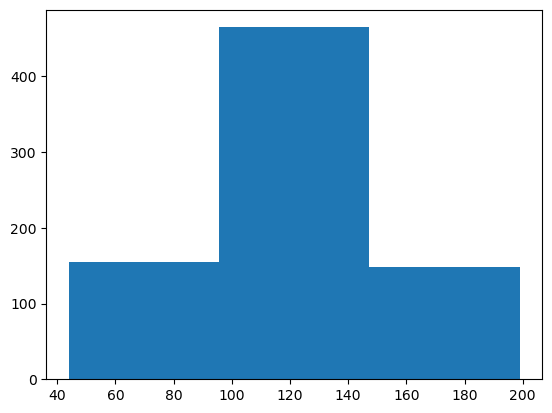

In [13]:
plt.hist(dia['Glucose'],bins=3)

(array([498., 262.,   8.]),
 array([18.2, 34.5, 50.8, 67.1]),
 <BarContainer object of 3 artists>)

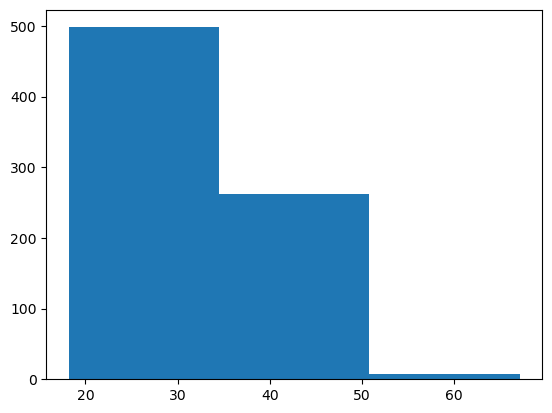

In [14]:
plt.hist(dia["BMI"],bins=3)

<Axes: xlabel='count', ylabel='Outcome'>

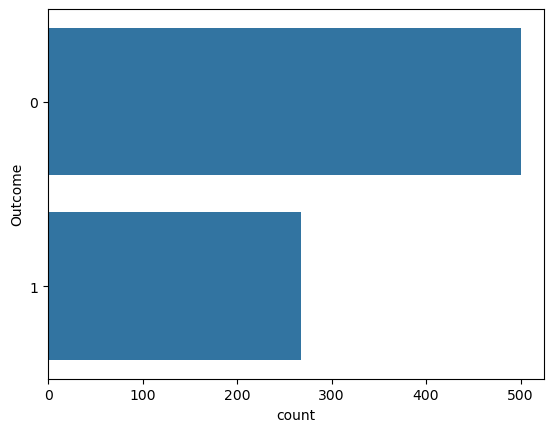

In [15]:
sns.countplot(y='Outcome',data=dia)

<Axes: >

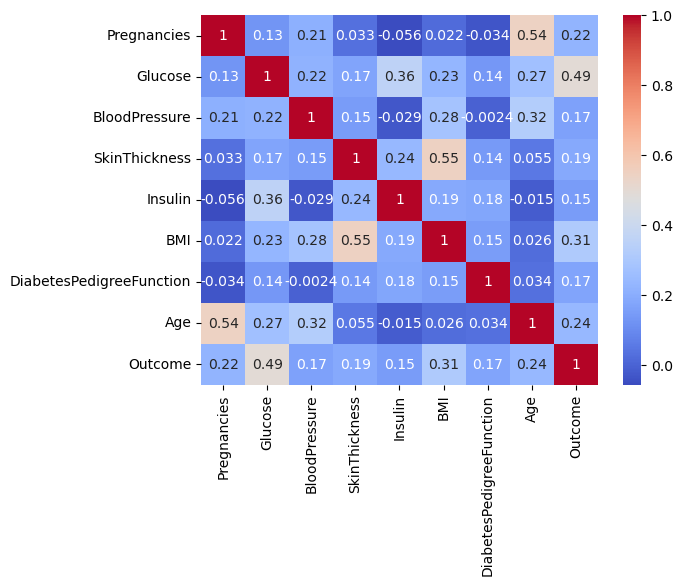

In [16]:
corr_mat = dia.corr(numeric_only=True)
sns.heatmap(corr_mat,annot=True,cmap='coolwarm')

In [17]:
X=dia.drop('Outcome',axis=1)
y=dia['Outcome']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [19]:
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test , y_pred)
print(accuracy)

0.7792207792207793


In [20]:
(dia[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']]==0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [21]:
print(dia.corr(numeric_only=True)['Outcome'].sort_values(ascending=False))

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312249
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.189065
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Insulin                     0.148457
Name: Outcome, dtype: float64


In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("accuracy:" ,accuracy)


accuracy: 0.7792207792207793


In [23]:
new_patient = [[2, 150, 80, 20, 100, 30.5, 0.5, 45]]

new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

print(prediction)

[1]


In [3]:
import os
import joblib

BASE_DIR = r"C:\Users\Harsh\ML-Projects\Diabetes predictor"

model = joblib.load(os.path.join(BASE_DIR, "diabetes_model.pkl"))
scaler = joblib.load(os.path.join(BASE_DIR, "scaler.pkl"))

print("Model and scaler loaded successfully!")

Model and scaler loaded successfully!


In [1]:
import os
print(os.getcwd())

C:\Users\Harsh\ML-Projects\Diabetes predictor


In [1]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Harsh\ML-Projects\Diabetes predictor
['.ipynb_checkpoints', 'app.py', 'code.ipynb', 'diabetes.csv', 'diabetes_model.pkl', 'scaler.pkl']
